# Desempeño de los modelos — tabla y figuras

**Tesis MSc — Oscar I. Sánchez P. | Capítulo 5, Sección 5.4.2**

Toma los archivos `set_A_mc_metrics.csv`, `set_B_mc_metrics.csv` y `set_C_mc_metrics.csv` que producen los tres paquetes de entrenamiento y genera:

1. **Tabla 5.x** — mediana de las siete métricas para cada modelo y cada paquete, con el rango intercuartil de las tres principales. Se exporta en CSV y en LaTeX listo para pegar.
2. **Figura de cajas** — la distribución de las 100 réplicas, tres paneles (una métrica cada uno), y dentro de cada panel los tres paquetes con sus tres modelos. Una sola figura en vez de tres, para poder comparar las dos dimensiones de un vistazo.
3. **Figura de trazas** — el valor de cada métrica corrida por corrida, de la 1 a la 100. Rejilla de 3 x 3: filas = métricas, columnas = paquetes.
4. **Comparación pareada entre modelos** — la diferencia entre modelos *dentro de la misma corrida*, que es una prueba mucho más potente que comparar las distribuciones por separado.

## Por qué estas tres métricas y no otras

| Métrica | Qué mide | Por qué va al frente |
|---|---|---|
| **AUROC** | discriminación: ¿ordena bien las dos clases? | no depende del corte ni de la prevalencia |
| **AP** (PR-AUC) | de las alertas emitidas, ¿cuántas serían reales? | no depende del corte, y es la cara operacional que el AUROC esconde |
| **Brier** | calibración: ¿las probabilidades significan lo que dicen? | los umbrales del capítulo son cortes sobre esas probabilidades |

`F1`, `recall`, `precision` y `POFA` se calculan en el corte fijo de 0.5, que con la razón 2:1 no es neutro. Van en la tabla como descripción, pero no deben usarse para decidir cuál modelo es mejor. Es lo mismo que dice la Sección 5.3.5.

> **Ojo con el Brier**: es el único de los tres en el que **menos es mejor**. En las figuras se marca con una flecha para que no se lea al revés.

## 1. Librerías y configuración

In [26]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

ANCHO = 10.46     # pulgadas = 467 pt, el \textwidth de tu documento

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 11,
    'axes.titlesize': 10,
    'axes.titleweight': 'bold',
    'axes.labelsize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 10,
    'figure.dpi': 110,
    'savefig.dpi': 300,
})

# ------------------------------------------------------------------ rutas
OUT_DIR = '/home/oisanchezp/Thesis/src/05_Chapter/Montecarlo/'
FIG_DIR = '00Figuras/05Seccion'
os.makedirs(FIG_DIR, exist_ok=True)

# ------------------------------------------------------------- etiquetas
SETS   = ['A', 'B', 'C']
MODELS = ['LR', 'GAM', 'RF']

MODEL_LABEL = {'LR': 'Logistic regression',
               'GAM': 'Generalized additive model',
               'RF': 'Random forest'}
MODEL_COLOR = {'LR': '#4c78a8', 'GAM': '#59a14f', 'RF': '#e15759'}

# métricas principales (independientes del corte) y secundarias
MAIN = ['auc', 'ap', 'brier']
SEC  = ['f1', 'recall', 'precision', 'pofd']

METRIC_LABEL = {
    'auc':       'AUROC',
    'ap':        'AP (PR-AUC)',
    'brier':     'Brier score',
    'f1':        r'$F_1$',
    'recall':    'Recall',
    'precision': 'Precision',
    'pofd':      'POFA',
}
# True  -> valores altos son mejores; False -> valores bajos son mejores
HIGHER_BETTER = {'auc': True, 'ap': True, 'brier': False,
                 'f1': True, 'recall': True, 'precision': True,
                 'pofd': False}

## 2. Carga de los tres paquetes

Se apilan en una sola tabla larga con una columna `set`. Si algún paquete todavía no se ha corrido, se omite con un aviso.

In [8]:
frames = []
for s in SETS:
    path = os.path.join(OUT_DIR, f'set_{s}_mc_metrics.csv')
    if not os.path.exists(path):
        print(f'AVISO: falta {path}, se omite el paquete {s}')
        continue
    d = pd.read_csv(path)
    d['set'] = s
    frames.append(d)

df = pd.concat(frames, ignore_index=True)
df['model'] = pd.Categorical(df['model'], categories=MODELS, ordered=True)
df['set']   = pd.Categorical(df['set'],   categories=SETS,   ordered=True)

SETS_OK = [s for s in SETS if s in df['set'].unique()]

print('Corridas por paquete y modelo:')
print(df.groupby(['set', 'model'], observed=True).size().unstack().to_string())
print('\nObservaciones por corrida (n):')
print(df.groupby('set', observed=True)['n'].agg(['min', 'median', 'max']).to_string())

Corridas por paquete y modelo:
model   LR  GAM   RF
set                 
A      100  100  100
B      100   97   97
C      100   94   94

Observaciones por corrida (n):
      min  median   max
set                    
A    1098  1098.0  1098
B    1094  1097.0  1098
C    1093  1097.0  1098


## 3. Tabla de desempeño

Mediana de las siete métricas. Para las tres principales se añade el rango intercuartil entre corchetes, porque es la medida de cuánto depende el resultado del azar del muestreo de ausencias. Para las cuatro secundarias basta la mediana: dependen del corte de 0.5 y solo describen.

In [9]:
def med_iqr(x, dec=3):
    """'0.951 [0.944-0.958]'"""
    return (f'{np.median(x):.{dec}f} '
            f'[{np.quantile(x, .25):.{dec}f}\u2013{np.quantile(x, .75):.{dec}f}]')


filas = []
for s in SETS_OK:
    for m in MODELS:
        sub = df[(df['set'] == s) & (df['model'] == m)]
        if sub.empty:
            continue
        fila = {'Set': s, 'Model': m, 'Runs': len(sub)}
        for k in MAIN:
            fila[METRIC_LABEL[k]] = med_iqr(sub[k].to_numpy())
        for k in SEC:
            fila[METRIC_LABEL[k]] = f'{sub[k].median():.3f}'
        filas.append(fila)

tabla = pd.DataFrame(filas)
print(tabla.to_string(index=False))
tabla.to_csv(os.path.join(OUT_DIR, 'performance_table.csv'), index=False)

# tabla completa con todos los cuantiles, por si la necesitas
full = (df.groupby(['set', 'model'], observed=True)[MAIN + SEC]
        .describe(percentiles=[.25, .5, .75]).round(4))
full.to_csv(os.path.join(OUT_DIR, 'performance_table_full.csv'))
print('\nGuardadas performance_table.csv y performance_table_full.csv')

Set Model  Runs               AUROC         AP (PR-AUC)         Brier score $F_1$ Recall Precision  POFA
  A    LR   100 0.949 [0.942–0.961] 0.891 [0.868–0.915] 0.087 [0.077–0.093] 0.813  0.784     0.846 0.074
  A   GAM   100 0.951 [0.945–0.961] 0.894 [0.872–0.916] 0.084 [0.075–0.090] 0.819  0.797     0.849 0.074
  A    RF   100 0.948 [0.939–0.957] 0.885 [0.862–0.911] 0.076 [0.069–0.084] 0.858  0.885     0.827 0.088
  B    LR   100 0.953 [0.940–0.962] 0.913 [0.897–0.937] 0.074 [0.066–0.082] 0.852  0.839     0.870 0.061
  B   GAM    97 0.957 [0.946–0.965] 0.921 [0.903–0.942] 0.071 [0.065–0.079] 0.861  0.847     0.875 0.060
  B    RF    97 0.963 [0.954–0.970] 0.940 [0.925–0.951] 0.069 [0.063–0.075] 0.866  0.840     0.902 0.047
  C    LR   100 0.972 [0.965–0.980] 0.951 [0.942–0.965] 0.054 [0.048–0.060] 0.894  0.888     0.907 0.046
  C   GAM    94 0.975 [0.967–0.981] 0.954 [0.942–0.966] 0.054 [0.046–0.060] 0.896  0.890     0.910 0.047
  C    RF    94 0.979 [0.971–0.985] 0.965 [0.951–0.974]

In [10]:
# ---------------- versión LaTeX lista para pegar ----------------------
print('\\renewcommand{\\arraystretch}{1.25}')
print('\\setlength{\\tabcolsep}{4pt}')
print('\\begin{table}[ht]')
print('\\centering')
print('\\scriptsize')
print('\\begin{tabular}{ll ccc cccc}')
print('\\hline')
print('\\textbf{Set} & \\textbf{Model} & \\textbf{AUROC} & \\textbf{AP} & '
      '\\textbf{Brier} & $\\mathbf{F_1}$ & \\textbf{Recall} & '
      '\\textbf{Precision} & \\textbf{POFA} \\\\')
print('\\hline')
for s in SETS_OK:
    for j, m in enumerate(MODELS):
        sub = df[(df['set'] == s) & (df['model'] == m)]
        if sub.empty:
            continue
        set_cell = s if j == 0 else ''
        celdas = [med_iqr(sub[k].to_numpy()) for k in MAIN]
        celdas = [c.replace('\u2013', '--') for c in celdas]
        celdas += [f'{sub[k].median():.3f}' for k in SEC]
        print(f'{set_cell} & {m} & ' + ' & '.join(celdas) + ' \\\\')
    print('\\hline')
print('\\end{tabular}')
print('\\caption{Predictive performance of the three models under the three '
      'training sets. Values are medians over the 100 Monte Carlo runs, with '
      'the interquartile range in brackets for the three metrics that do not '
      'depend on the probability cut-off. $F_1$, recall, precision and POFA '
      'were computed at a fixed cut-off of 0.5 and are reported as a '
      'description only. Lower is better for the Brier score and for POFA; '
      'higher is better for the rest.}')
print('\\label{tab:th-performance}')
print('\\end{table}')

\renewcommand{\arraystretch}{1.25}
\setlength{\tabcolsep}{4pt}
\begin{table}[ht]
\centering
\scriptsize
\begin{tabular}{ll ccc cccc}
\hline
\textbf{Set} & \textbf{Model} & \textbf{AUROC} & \textbf{AP} & \textbf{Brier} & $\mathbf{F_1}$ & \textbf{Recall} & \textbf{Precision} & \textbf{POFA} \\
\hline
A & LR & 0.949 [0.942--0.961] & 0.891 [0.868--0.915] & 0.087 [0.077--0.093] & 0.813 & 0.784 & 0.846 & 0.074 \\
 & GAM & 0.951 [0.945--0.961] & 0.894 [0.872--0.916] & 0.084 [0.075--0.090] & 0.819 & 0.797 & 0.849 & 0.074 \\
 & RF & 0.948 [0.939--0.957] & 0.885 [0.862--0.911] & 0.076 [0.069--0.084] & 0.858 & 0.885 & 0.827 & 0.088 \\
\hline
B & LR & 0.953 [0.940--0.962] & 0.913 [0.897--0.937] & 0.074 [0.066--0.082] & 0.852 & 0.839 & 0.870 & 0.061 \\
 & GAM & 0.957 [0.946--0.965] & 0.921 [0.903--0.942] & 0.071 [0.065--0.079] & 0.861 & 0.847 & 0.875 & 0.060 \\
 & RF & 0.963 [0.954--0.970] & 0.940 [0.925--0.951] & 0.069 [0.063--0.075] & 0.866 & 0.840 & 0.902 & 0.047 \\
\hline
C & LR & 0.972 [0.965-

## 4. Figura de cajas

Un panel por métrica principal. Dentro de cada panel, los paquetes en el eje horizontal y los tres modelos agrupados en cada paquete. Así se leen las dos comparaciones a la vez: entre modelos (dentro de un paquete) y entre paquetes (misma posición relativa).

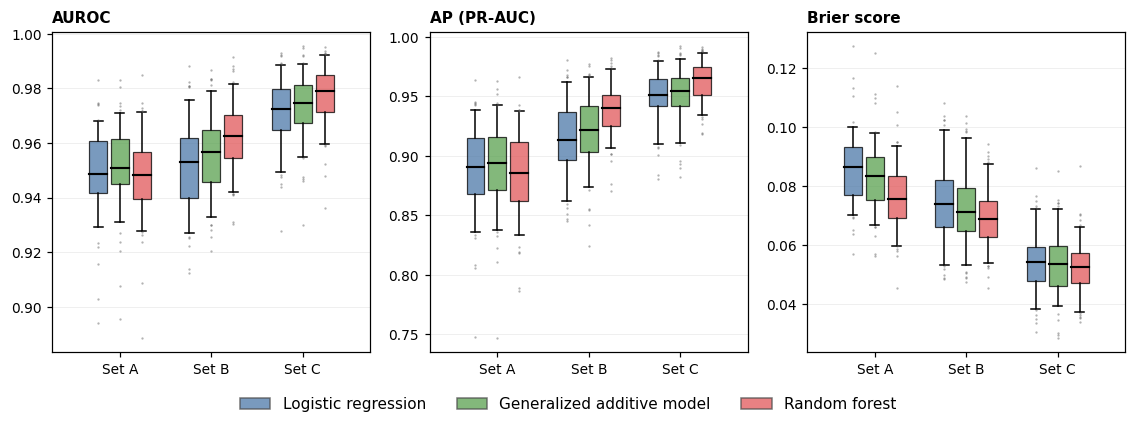

In [27]:
W = 0.24   # ancho de cada caja

fig, axes = plt.subplots(1, 3, figsize=(ANCHO, ANCHO * 0.35), sharey=False)

for ax, k in zip(axes, MAIN):
    for i, s in enumerate(SETS_OK):
        for j, m in enumerate(MODELS):
            vals = df.loc[(df['set'] == s) & (df['model'] == m), k].dropna()
            if vals.empty:
                continue
            bp = ax.boxplot(vals.to_numpy(), positions=[i + (j - 1) * W],
                            widths=W * 0.82, patch_artist=True,
                            showfliers=True, whis=(5, 95),
                            medianprops=dict(color='black', lw=1.4),
                            flierprops=dict(marker='.', ms=3,
                                            mfc='0.4', mec='none', alpha=.5))
            for box in bp['boxes']:
                box.set(facecolor=MODEL_COLOR[m], alpha=.75, lw=.8)

    ax.set_xticks(range(len(SETS_OK)))
    ax.set_xticklabels([f'Set {s}' for s in SETS_OK])
    ax.set_title(METRIC_LABEL[k], loc='left')
    ax.grid(axis='y', alpha=.25, lw=.5)
    ax.set_axisbelow(True)
    #flecha = '\u2191 better' if HIGHER_BETTER[k] else '\u2193 better'
    #ax.annotate(flecha, xy=(0.99, 0.02), xycoords='axes fraction',
    #            ha='right', va='bottom', fontsize=8, color='0.35')

handles = [Patch(facecolor=MODEL_COLOR[m], alpha=.75, edgecolor='0.3',
                 label=MODEL_LABEL[m]) for m in MODELS]
fig.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, 0.03),
           ncol=3, frameon=False)

fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'fig_performance_box.pdf'), dpi=300, bbox_inches='tight')
fig.savefig(os.path.join(FIG_DIR, 'fig_performance_box.png'), dpi=300, bbox_inches='tight')
plt.show()

## 5. Figura de trazas

Cada métrica corrida por corrida, de la 1 a la 100. Sirve para dos cosas: ver la magnitud del ruido de muestreo y comprobar que no hay tendencia ni saltos, que indicarían un problema en la construcción de los datasets.

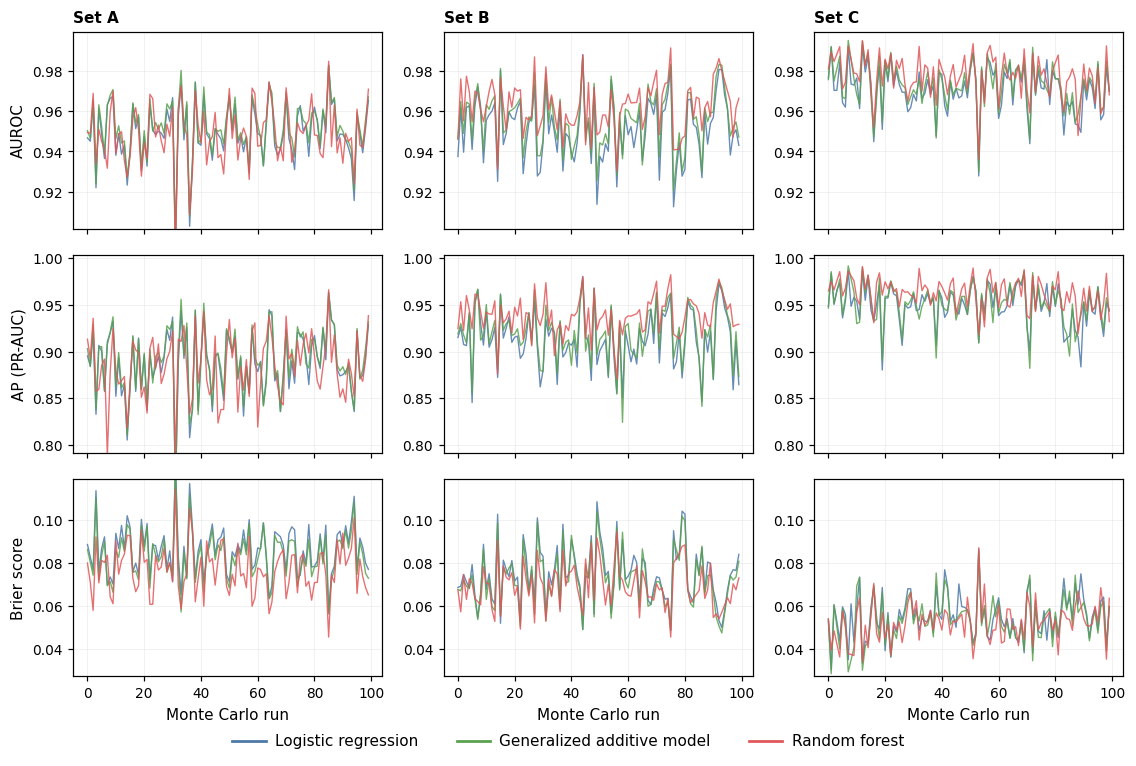

In [28]:
from matplotlib.lines import Line2D


fig, axes = plt.subplots(len(MAIN), len(SETS_OK),
                         figsize=(ANCHO, ANCHO *0.65),
                         sharex=True, squeeze=False)

for r, k in enumerate(MAIN):
    # mismo eje vertical en toda la fila, para poder comparar paquetes
    lo = df[k].quantile(0.005)
    hi = df[k].quantile(0.995)
    pad = 0.08 * (hi - lo)
    for c, s in enumerate(SETS_OK):
        ax = axes[r][c]
        for m in MODELS:
            sub = (df[(df['set'] == s) & (df['model'] == m)]
                   .sort_values('run_id'))
            if sub.empty:
                continue
            ax.plot(sub['run_id'], sub[k], lw=.9, alpha=.85,
                    color=MODEL_COLOR[m], label=MODEL_LABEL[m])
            # ax.axhline(sub[k].median(), color=MODEL_COLOR[m],
            #            ls=':', lw=1.0, alpha=.9)
        ax.set_ylim(lo - pad, hi + pad)
        ax.grid(alpha=.22, lw=.5)
        ax.set_axisbelow(True)
        if r == 0:
            ax.set_title(f'Set {s}', loc='left')
        if c == 0:
            ax.set_ylabel(METRIC_LABEL[k])
        if r == len(MAIN) - 1:
            ax.set_xlabel('Monte Carlo run')

# Handles explícitos: uno por modelo, no los 9 que genera el bucle
handles = [Line2D([], [], color=MODEL_COLOR[m], lw=1.8, label=MODEL_LABEL[m])
           for m in MODELS]

fig.tight_layout(rect=[0, 0.06, 1, 1])

fig.legend(handles=handles, loc='lower center', bbox_to_anchor=(0.5, -0.030),
           ncol=3, frameon=False,
           columnspacing=2.5, handlelength=2.2, handletextpad=0.6)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'fig_performance_runs.pdf'), dpi=300, bbox_inches='tight')
fig.savefig(os.path.join(FIG_DIR, 'fig_performance_runs.png'), dpi=300, bbox_inches='tight')
plt.show()

## 6. Comparación pareada entre modelos

Comparar las medianas de dos modelos ignora que en cada corrida **los tres modelos vieron exactamente los mismos datos**. La comparación correcta es la diferencia dentro de cada corrida.

La pregunta que responde: *¿el GAM le gana a la logística en la misma corrida, y en qué fracción de las 100?* Si la diferencia mediana es minúscula y el GAM gana solo en la mitad de las corridas, los modelos son indistinguibles, y eso es un resultado del capítulo.

In [29]:
pares = [('GAM', 'LR'), ('RF', 'LR'), ('RF', 'GAM')]
filas = []

for s in SETS_OK:
    for k in MAIN:
        w = (df[df['set'] == s]
             .pivot(index='run_id', columns='model', values=k))
        for a, b in pares:
            if a not in w.columns or b not in w.columns:
                continue
            d = (w[a] - w[b]).dropna()
            gana = (d > 0).mean() if HIGHER_BETTER[k] else (d < 0).mean()
            filas.append({
                'Set': s, 'Metric': METRIC_LABEL[k], 'Comparison': f'{a} - {b}',
                'Median diff': round(d.median(), 4),
                'IQR': f'[{d.quantile(.25):.4f}, {d.quantile(.75):.4f}]',
                f'Runs where {a} wins': f'{100*gana:.0f}%',
            })

pareada = pd.DataFrame(filas)
print(pareada.to_string(index=False))
pareada.to_csv(os.path.join(OUT_DIR, 'performance_paired.csv'), index=False)

print('\nLECTURA: si la diferencia mediana es mucho menor que el IQR de la')
print('metrica (mira la tabla del punto 3) y el porcentaje de victorias esta')
print('cerca del 50%, los dos modelos son indistinguibles en ese paquete.')

Set      Metric Comparison  Median diff                IQR Runs where GAM wins Runs where RF wins
  A       AUROC   GAM - LR       0.0020   [0.0010, 0.0036]                 87%                NaN
  A       AUROC    RF - LR      -0.0012  [-0.0061, 0.0043]                 NaN                46%
  A       AUROC   RF - GAM      -0.0036  [-0.0081, 0.0024]                 NaN                39%
  A AP (PR-AUC)   GAM - LR       0.0028  [-0.0007, 0.0063]                 72%                NaN
  A AP (PR-AUC)    RF - LR      -0.0027  [-0.0220, 0.0158]                 NaN                46%
  A AP (PR-AUC)   RF - GAM      -0.0067  [-0.0234, 0.0111]                 NaN                43%
  A Brier score   GAM - LR      -0.0025 [-0.0039, -0.0017]                 95%                NaN
  A Brier score    RF - LR      -0.0096 [-0.0132, -0.0054]                 NaN                93%
  A Brier score   RF - GAM      -0.0071 [-0.0102, -0.0029]                 NaN                83%
  B       AUROC   GA

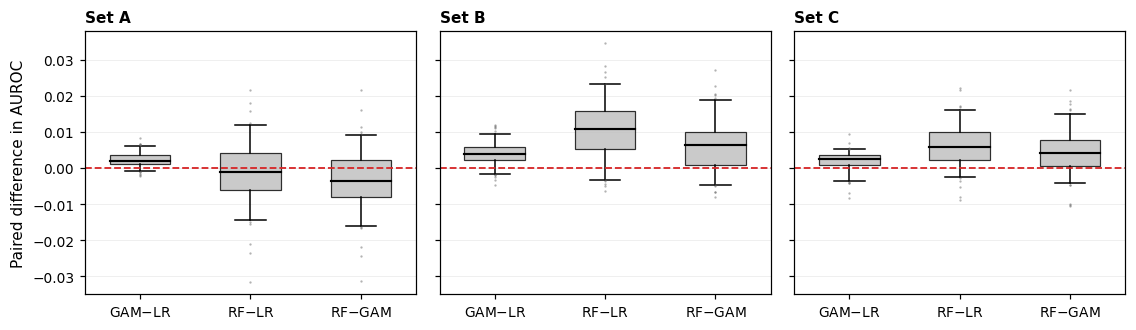

In [30]:
# --- figura de la comparacion pareada (una fila por paquete) -----------
fig, axes = plt.subplots(1, len(SETS_OK), figsize=(ANCHO, ANCHO * 0.30),
                         squeeze=False, sharey=True)

for c, s in enumerate(SETS_OK):
    ax = axes[0][c]
    w = (df[df['set'] == s].pivot(index='run_id', columns='model', values='auc'))
    datos, etiquetas = [], []
    for a, b in pares:
        if a in w.columns and b in w.columns:
            datos.append((w[a] - w[b]).dropna().to_numpy())
            etiquetas.append(f'{a}$-${b}')
    bp = ax.boxplot(datos, patch_artist=True, widths=.55, whis=(5, 95),
                    medianprops=dict(color='black', lw=1.4),
                    flierprops=dict(marker='.', ms=3, mfc='0.4',
                                    mec='none', alpha=.5))
    for box in bp['boxes']:
        box.set(facecolor='#bdbdbd', alpha=.8, lw=.8)
    ax.axhline(0, color='#d62728', lw=1.2, ls='--')
    ax.set_xticklabels(etiquetas)
    ax.set_title(f'Set {s}', loc='left')
    ax.grid(axis='y', alpha=.25, lw=.5)
    ax.set_axisbelow(True)
    if c == 0:
        ax.set_ylabel('Paired difference in AUROC')

fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'fig_performance_paired.pdf'), dpi=300, bbox_inches='tight')
fig.savefig(os.path.join(FIG_DIR, 'fig_performance_paired.png'), dpi=300, bbox_inches='tight')
plt.show()

## 7. Cifras sueltas para redactar la sección

In [12]:
print('=== AUROC: mediana por paquete y modelo ===')
print(df.pivot_table(index='set', columns='model', values='auc',
                     aggfunc='median', observed=True).round(3).to_string())

print('\n=== Dispersion tipica (IQR del AUROC) ===')
iqr = (df.groupby(['set', 'model'], observed=True)['auc']
       .agg(lambda x: x.quantile(.75) - x.quantile(.25)).round(4))
print(iqr.unstack().to_string())

print('\n=== Rango entre modelos frente al ruido, por paquete ===')
for s in SETS_OK:
    sub = df[df['set'] == s]
    meds = sub.groupby('model', observed=True)['auc'].median()
    rango = meds.max() - meds.min()
    ruido = sub.groupby('model', observed=True)['auc'].std().median()
    print(f'  Set {s}: rango entre modelos={rango:.4f} | '
          f'sd tipica entre corridas={ruido:.4f} | '
          f'razon={rango/max(ruido,1e-9):.2f}')
print('\nSi la razon es menor que 1, la diferencia entre modelos es mas')
print('pequena que el ruido del muestreo: los modelos empatan.')

=== AUROC: mediana por paquete y modelo ===
model     LR    GAM     RF
set                       
A      0.951  0.952  0.951
B      0.956  0.959  0.965
C      0.971  0.974  0.979

=== Dispersion tipica (IQR del AUROC) ===
model      LR     GAM      RF
set                          
A      0.0154  0.0150  0.0152
B      0.0208  0.0183  0.0175
C      0.0122  0.0110  0.0120

=== Rango entre modelos frente al ruido, por paquete ===
  Set A: rango entre modelos=0.0015 | sd tipica entre corridas=0.0124 | razon=0.12
  Set B: rango entre modelos=0.0087 | sd tipica entre corridas=0.0123 | razon=0.71
  Set C: rango entre modelos=0.0079 | sd tipica entre corridas=0.0095 | razon=0.83

Si la razon es menor que 1, la diferencia entre modelos es mas
pequena que el ruido del muestreo: los modelos empatan.


---

## Captions sugeridos

```latex
\caption{Predictive performance of the three models under the three training sets, over the 100 Monte Carlo runs. (a) AUROC, (b) area under the precision--recall curve, (c) Brier score. Boxes span the interquartile range, whiskers the 5th and 95th percentiles, and the line inside each box is the median. Higher is better in (a) and (b), lower is better in (c).}
\label{fig:th-performance}
```

```latex
\caption{The same three metrics run by run. Rows are metrics, columns are training sets, and the dotted lines mark the median of each model. The spread between runs measures how much the result depends on which non-landslide observations happened to be drawn; the absence of any trend along the horizontal axis confirms that the resampling behaves as intended.}
\label{fig:th-performance-runs}
```

```latex
\caption{Paired difference in AUROC between models, computed within each Monte Carlo run so that the three models are compared on exactly the same data. The dashed line marks no difference.}
\label{fig:th-performance-paired}
```